In [1]:
# Импортируем необходимые библиотеки

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

In [2]:
# Загружаем данные 

df = pd.read_csv('Titanic-Dataset.csv')

In [3]:
# Посмотрим на первые 5 колонок

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Посмотрим на размерность

df.shape

(891, 12)

In [5]:
# Посмотрим на заполнненные значения и типы данных

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# Посмотрим на кол-во пропусков в каждом признаке

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Посмотрим есть ли выбросы

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Посмотрим на строки фьючи Age, где есть пропуски

df[df.Age.isnull()==True]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [9]:
# Заполним пропуски в колоке Age средним значением для каждой группы

df['Age'] = df['Age'].fillna(df.groupby('Sex')['Age'].transform('mean'))

In [10]:
# Посмотрим вообще на данные где указана кабина

df[df.Cabin.isnull()==False]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


У нас осталось две колонки с пропусками Cabin(687) и Embarked(2). Колонки Cabin, Name, Ticket, PassengerId - неинформативные и будут бесполезны для модели - удаляем,  Embarked - заполним модой

In [11]:
# Удалим колонки

df = df.drop(columns=['Cabin', 'Name','PassengerId', 'Ticket'])

In [12]:
# Заполним модой Embarked

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
# Снова посмотрим на кол-во пропусков

df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [27]:
# Проверим кол-во дубликатов

df.duplicated().sum()

np.int64(111)

In [26]:
df[df.duplicated()]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
47,1,3,female,27.915709,0,0,7.7500,Q
76,0,3,male,30.726645,0,0,7.8958,S
77,0,3,male,30.726645,0,0,8.0500,S
87,0,3,male,30.726645,0,0,8.0500,S
95,0,3,male,30.726645,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
870,0,3,male,26.000000,0,0,7.8958,S
877,0,3,male,19.000000,0,0,7.8958,S
878,0,3,male,30.726645,0,0,7.8958,S
884,0,3,male,25.000000,0,0,7.0500,S


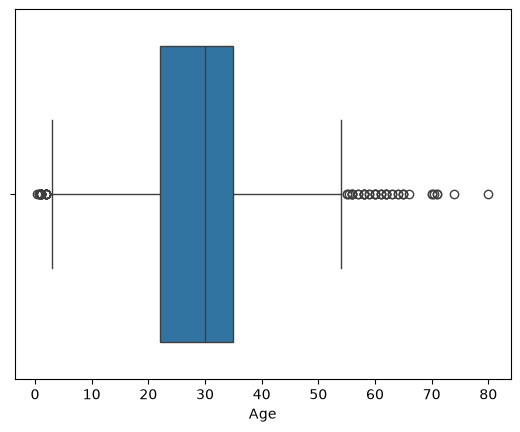

In [15]:
sns.boxplot(x=df['Age'])
plt.show()

In [16]:
df_cleaned = df.copy(deep=True)

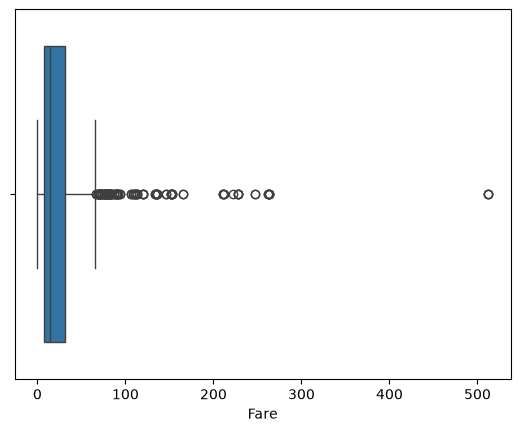

In [17]:
sns.boxplot(x=df_cleaned['Fare'])
plt.show()

In [18]:
# заменяем старый
df_cleaned['Fare'] = np.log1p(df_cleaned['Fare'])

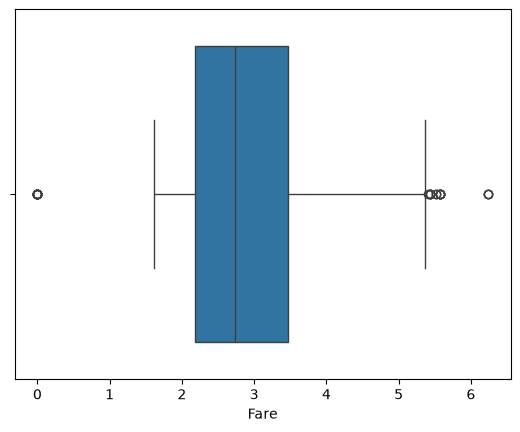

In [19]:
sns.boxplot(x=df_cleaned['Fare'])
plt.show()

In [20]:
# Кодируем текстовые переменные в числа (One-Hot Encoding)

df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

In [21]:
df_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,1,0,1
1,1,1,38.000000,1,0,71.2833,0,0,0
2,1,3,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,0,1
887,1,1,19.000000,0,0,30.0000,0,0,1
888,0,3,27.915709,1,2,23.4500,0,0,1
889,1,1,26.000000,0,0,30.0000,1,0,0


In [22]:
# Обозначем X, y

X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [24]:
# 1. Создаем и обучаем масштабировщик (только на тренировочных данных!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# 2. Инициализируем модель
model = LogisticRegression()

# 3. Обучаем модель НА ОТМАСШТАБИРОВАННЫХ данных
model.fit(X_train_scaled, y_train)

# 4. Делаем предсказания тоже НА ОТМАСШТАБИРОВАННЫХ данных
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)


In [31]:
# Получаем вероятности для тест и трейн выборок (индекс [:, 1] берет класс "1" — выжил)
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]

# Считаем корректный ROC-AUC
print("ROC-AUC на тесте:", round(roc_auc_score(y_test, y_proba_test),4))
print("ROC-AUC на трейне:", round(roc_auc_score(y_train, y_proba_train),4))


ROC-AUC на тесте: 0.8806
ROC-AUC на трейне: 0.8465
